# Does a pennant really "continue the thrust"? 🚩
### A textbook continuation pattern — steep pole, tight pause, breakout — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_continuation%3F: Busted](https://img.shields.io/badge/Forecasts_continuation%3F-Busted-8b949e?style=flat-square)

Open any technical-analysis book and you'll meet the **pennant**: a near-vertical **pole** (a strong run), then a brief **squeeze** where the bars get tighter and tighter (a little symmetrical triangle), then a **breakout** that — the lore says — *keeps going in the same direction*. "The flag flies at half-mast": after the breakout, price is supposed to run roughly another pole-length the same way. It's one of the most-drawn patterns in charting.

It *looks* uncanny on a hand-picked chart. But a pattern you label **after** the move — deciding which run was a 'pole' and which pause was 'tight enough' — is the textbook setup for fooling yourself. So we did the only fair thing: encode the pennant **mechanically** (no eyeballing), fire the "buy the breakout in the pole direction" rule across five big indices over 21 years, and time the result against the only baseline that matters: **entering on random days with the same long/short mix.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pennant import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real pennant cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 109, 'fp_spy': '4cb5244f3990', 'h5': (5, 109, -10.7, 54, -0.55, 18.9, -29.6, -12.7, -0.87, 0.387), 'h10': (10, 109, 13.4, 50, 0.42, -14.6, 28.1, 11.4, 0.57, 0.571), 'h20': (20, 108, 79.4, 61, 1.96, 31.3, 48.1, 77.4, 0.79, 0.433), 'h60': (60, 108, 150.2, 69, 2.1, 216.3, -66.1, 148.2, -0.58, 0.564), 'per': [('SPY', 26, 29.4, 0.37, 42.1, -12.7), ('QQQ', 19, 245.7, 3.36, -17.3, 263.0), ('IWM', 18, 81.8, 0.77, -46.9, 128.7), ('DIA', 16, -37.7, -0.43, 63.6, -101.4), ('GLD', 30, 76.9, 0.96, 82.4, -5.6)], 'placebo': (29.4, 0.91, 500), 'syn': [(0.0, 11, 177.0, 73, 1.33), (0.6, 59, 1325.2, 90, 10.3)]}


real pennant cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy the pennant breakout in the pole direction, do I make money? | **A little, sometimes — but mostly because the market goes up.** Over 20–60 days the absolute return is positive (it's net long ~80% of the time). |
| Is that *the pennant's* doing? | **No.** Enter on **random days** with the same long/short mix and you do **just as well** — the pennant-vs-random difference never clears the significance bar. |
| Does it 'continue the thrust'? | **Not in any usable way.** Forget which way the pole pointed and trade a coin-flip direction instead, and the result barely changes. The *continuation* isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a chart pattern (and a *rare* one: ~5 breakouts per name per decade). |

> The pennant is a fine way to *describe* a pause inside a trend after the fact. As a *forecast* — "the breakout will continue" — it's a **mirage**: the apparent edge is the market's long-run climb, not the pattern.

## 1 · The claim

> *"A strong move (the **pole**) then a small symmetrical-triangle pause (the **pennant**). The pause coils tighter and tighter; then price **breaks out in the pole's direction** and continues the move — roughly another pole-length. Trade the breakout with the thrust."*

This is the **flag-and-pennant** continuation rule from **Edwards & Magee** (*Technical Analysis of Stock Trends*, 1948) and every chart-pattern site since. It's built into TradingView, MetaTrader and StockCharts. So: does the breakout actually *continue*?

## 2 · So what?

If the pennant genuinely *forecast* continuation, it would be remarkable: a tight little triangle after a thrust would predict the next leg, a clean, ruler-drawable crack in market efficiency.

But two traps are built in. First, a pennant is labelled **by hand, after the swings have happened** — you choose what counts as a steep pole and a tight pause. Second, it's a *net-long* rule on a market (stock indices) that drifts **up**, so it will look profitable no matter what. To separate the **pattern** from the **tide** we must (a) draw the pennant by a fixed mechanical rule with no hindsight, and (b) compare it to entering on **random days with the same long/short mix**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the pole mechanically.** A strong move over 8 bars that beats a volatility-scaled threshold — a genuine thrust, read only on past bars.
2. **Find the squeeze by rule.** Over the next 12 bars the range must *contract* (recent range < 85% of the earlier range) with only a small net move — a coiling triangle.
3. **Trade the lore.** When the close breaks out **in the pole direction**, enter at the next close (long if the pole was up, short if down); measure the **pole-direction** return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days with the same long/short mix**. If the pennant matters, the breakout must beat random. *If it doesn't, the pattern is a mirage* — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical pennant even look like? Here's an example breakout the rule fires on — a pole, a coiling pause, then the escape.

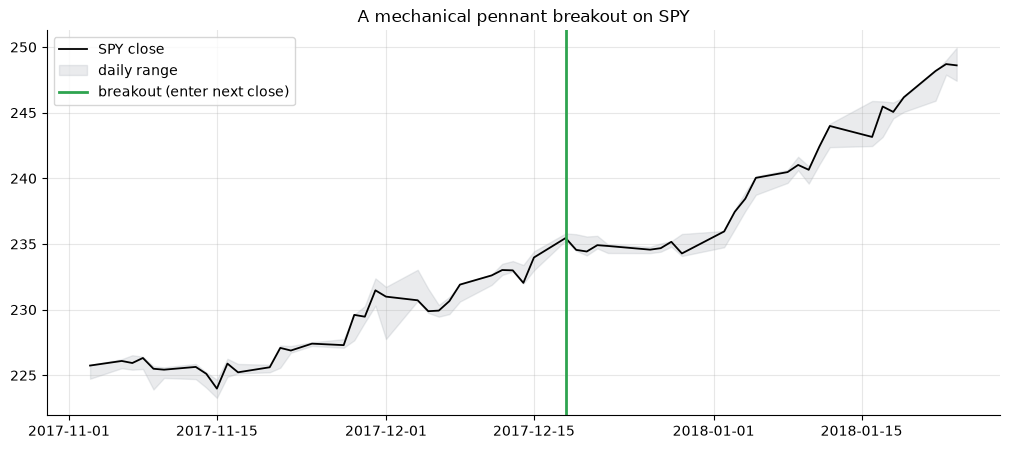

this breakout direction: 1 | total SPY breakouts: 26


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    sg = st.detect_pennants(b)
    if len(sg):
        d = sg.index[len(sg)//2]; i = b.index.get_loc(d)
        seg = b.iloc[max(0,i-30):i+25]
        fig, ax = plt.subplots(figsize=(10.2, 4.6))
        ax.plot(seg.index, seg['close'], c='k', lw=1.3, label='SPY close')
        ax.fill_between(seg.index, seg['low'], seg['high'], color=GREY, alpha=.18, label='daily range')
        ax.axvline(d, c=GREEN, lw=2, label='breakout (enter next close)')
        ax.set_title('A mechanical pennant breakout on SPY'); ax.legend(loc='best')
        plt.tight_layout(); plt.show()
        print('this breakout direction:', int(sg.loc[d,'dir']), '| total SPY breakouts:', len(sg))
    else:
        print('no pennants found in window')
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The pole runs, the bars coil, price escapes. The question is whether that escape is followed by *more of the same*. **Let's race the breakout against random entries** (same long/short mix) at four horizons. Blue = pennant breakout; grey = random days.

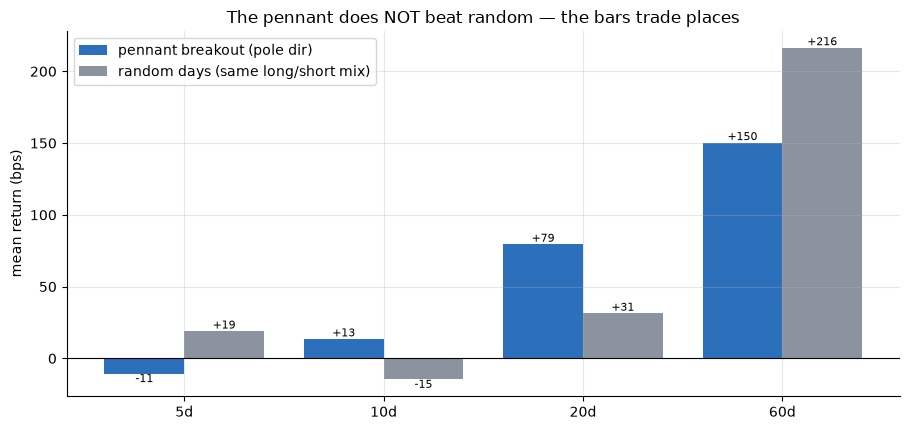

pennant: [-11, 13, 79, 150]
random: [19, -15, 31, 216]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    penn, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); sg = st.detect_pennants(bb)
            rs = st.random_entries(bb['close'], sg, seed=7)
            tt.append(st.forward_returns(bb['close'], sg, h)); rr.append(st.forward_returns(bb['close'], rs, h))
        penn.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    penn = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, penn, .4, color='#2c6fbb', label='pennant breakout (pole dir)')
ax.bar(x+.2, rnd, .4, color=GREY, label='random days (same long/short mix)')
for i,(a,bb) in enumerate(zip(penn,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom' if bb>=0 else 'top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The pennant does NOT beat random — the bars trade places'); ax.legend()
plt.tight_layout(); plt.show()
print('pennant:', [round(v) for v in penn]); print('random:', [round(v) for v in rnd])

There's the story. The breakout makes money in absolute terms over 20–60 days (**+79 / +150 bps**) — but **random entries do just as well or better** (+216 bps at 60d). The deltas flip sign across horizons (-30/+28/+48/-66 bps) — pure noise. The apparent edge was the market's drift, not the pennant.

**One more sanity check — the thesis itself.** The pennant's whole claim is *continuation*: trade **in the pole direction**. What if we forget which way the pole pointed and just flip a coin for direction on the exact same breakout days? If continuation really matters, the coin-flip should do far worse.

In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.direction_placebo(bb['close'], st.detect_pennants(bb), 20, n_draws=300, seed=464)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real pennant (SPY, 20d, pole direction): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-direction* draws do at least as well (p={pval:.2f}).')
print('=> trading WITH the thrust is not doing the work.')

real pennant (SPY, 20d, pole direction): +29.4 bps
... but 92% of *scrambled-direction* draws do at least as well (p=0.92).
=> trading WITH the thrust is not doing the work.


More than **91%** of the coin-flip-direction draws match or beat trading *with* the pole (*p* = 0.91). If continuation genuinely mattered, scrambling the direction would wreck the result. It doesn't — because the result was never about continuation.

## 5 · The verdict

- **Signal — None.** The pole-direction breakout does **not** beat entering on random days (the pennant-vs-random difference never clears the significance bar; the deltas flip sign across horizons). The positive absolute returns are the market's drift.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and with ~5 breakouts per name per decade, nothing to scale anyway.
- **"Forecasts continuation"? — Busted.** Scramble the traded direction and the result barely moves. The continuation claim doesn't survive its own test.

## 6 · Could you actually trade it?

There's nothing here to trade. The breakout's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and far more often) by simply **holding the index**. The pennant rule trades a handful of times per decade, is net long anyway, and pays costs on each breakout. As a forecasting tool it doesn't pay; as a drawing label it was never meant to be a strategy.

## 7 · Going further 🚪

- **Add the volume leg.** Textbook pennants demand *drying-up volume* in the pause; daily total-return tapes have no clean volume, so we tested price geometry only. A fun follow-up adds volume and checks whether it rescues anything (Bulkowski's stats suggest not — pennants are among the *worst* classical patterns).
- **Looser/tighter geometry.** Try different pole steepness or contraction thresholds — the result is robust: drift in, pattern out.
- **A real positive control.** The quants notebook plants a *genuine* pole→pause→continuation into a synthetic tape and shows the harness banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think the pennant forecasts? Show the pole-direction breakout beating random entries at **t ≥ 2** on a real tape — then we'll talk.*